In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("distillation_dataset.csv")

print(df.head())
print(df.shape)

   Row  Temp  Reflux  Stages  Feed_x      xD      xB      QC      QR
0    1    80     2.0      10     0.5  0.8429  0.0373  632.50  660.10
1    2    60     2.0      10     0.3  0.5258  0.0122  623.95  695.95
2    3    60     2.0      10     0.5  0.5258  0.0122  623.90  695.90
3    4    60     2.0      10     0.7  0.9865  0.2904  651.80  701.60
4    5    70     2.0      10     0.3  0.5257  0.0123  623.96  678.64
(30, 9)


In [27]:
X = df[["Temp", "Reflux", "Stages", "Feed_x"]]
y = df[["xD", "xB", "QC", "QR"]]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [29]:
def evaluate_model(y_true, y_pred, name):
    print(f"\n{name} Results:")
    
    for i, col in enumerate(["xD", "xB", "QC", "QR"]):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        r2 = r2_score(y_true.iloc[:, i], y_pred[:, i])
        
        print(f"{col}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

In [30]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

evaluate_model(y_test, y_pred_lr, "Linear Regression")


Linear Regression Results:
xD: MAE=0.0554, RMSE=0.0607, R2=0.9111
xB: MAE=0.0666, RMSE=0.0688, R2=0.7178
QC: MAE=3.5926, RMSE=4.1841, R2=0.9978
QR: MAE=2.8061, RMSE=3.5015, R2=0.9987


In [31]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

evaluate_model(y_test, y_pred_rf, "Random Forest")


Random Forest Results:
xD: MAE=0.1807, RMSE=0.1992, R2=0.0407
xB: MAE=0.0672, RMSE=0.0925, R2=0.4893
QC: MAE=10.1453, RMSE=11.1529, R2=0.9841
QR: MAE=9.3215, RMSE=11.3700, R2=0.9866


In [32]:
from sklearn.preprocessing import StandardScaler

# Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)

# ANN model
ann = MLPRegressor(hidden_layer_sizes=(100,100), max_iter=5000, random_state=42)

ann.fit(X_train_scaled, y_train_scaled)

# Predict
y_pred_scaled = ann.predict(X_test_scaled)
y_pred_ann = scaler_y.inverse_transform(y_pred_scaled)

# Evaluate
evaluate_model(y_test, y_pred_ann, "Improved ANN")


Improved ANN Results:
xD: MAE=0.0457, RMSE=0.0520, R2=0.9345
xB: MAE=0.0307, RMSE=0.0333, R2=0.9340
QC: MAE=8.1403, RMSE=8.5595, R2=0.9906
QR: MAE=7.4822, RMSE=9.1367, R2=0.9913


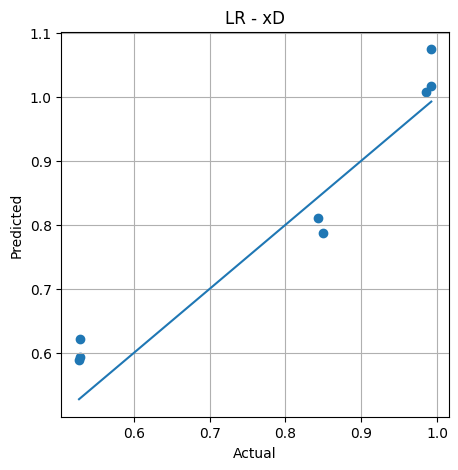

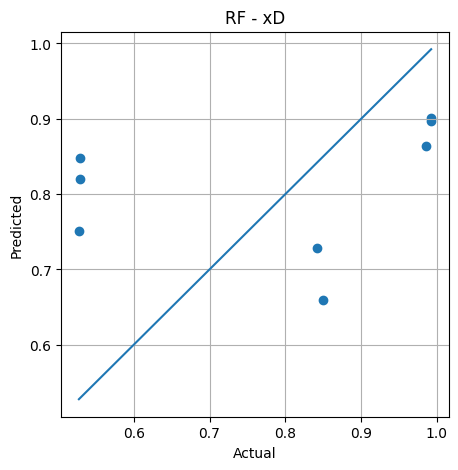

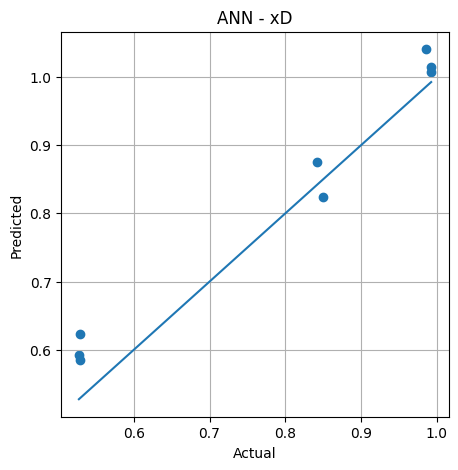

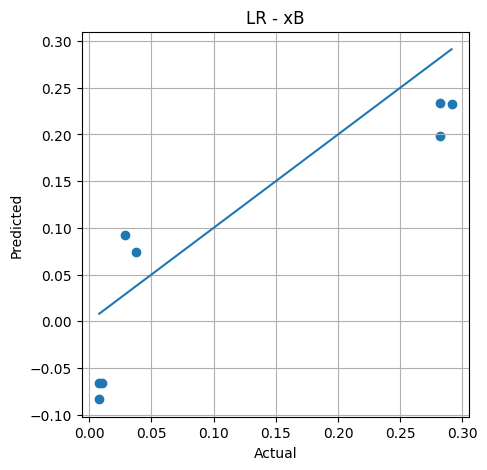

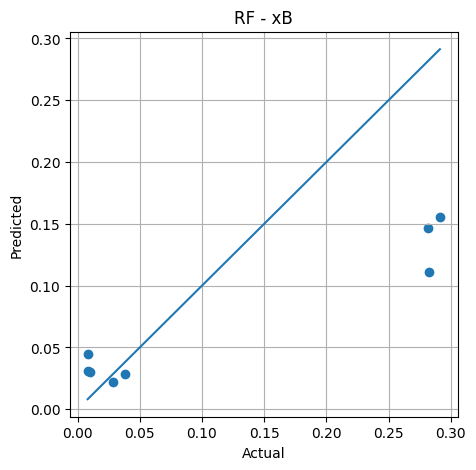

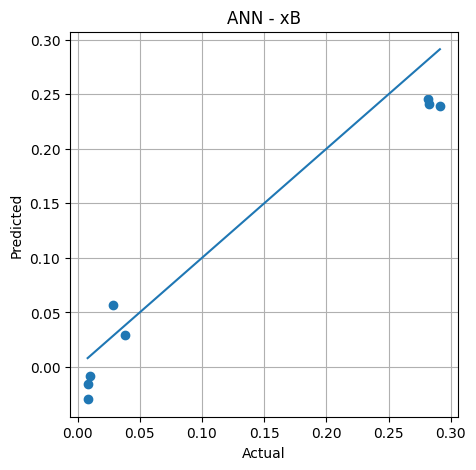

In [33]:
def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])
    plt.grid()
    plt.show()

# xD plots
plot_results(y_test["xD"], y_pred_lr[:,0], "LR - xD")
plot_results(y_test["xD"], y_pred_rf[:,0], "RF - xD")
plot_results(y_test["xD"], y_pred_ann[:,0], "ANN - xD")

# xB plots
plot_results(y_test["xB"], y_pred_lr[:,1], "LR - xB")
plot_results(y_test["xB"], y_pred_rf[:,1], "RF - xB")
plot_results(y_test["xB"], y_pred_ann[:,1], "ANN - xB")

In [34]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "ANN": y_pred_ann
}

for model_name, pred in models.items():
    print(f"\n{model_name}")
    for i, col in enumerate(["xD", "xB", "QC", "QR"]):
        mae, rmse, r2 = get_metrics(y_test.iloc[:, i], pred[:, i])
        print(f"{col}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")


Linear Regression
xD: MAE=0.0554, RMSE=0.0607, R2=0.9111
xB: MAE=0.0666, RMSE=0.0688, R2=0.7178
QC: MAE=3.5926, RMSE=4.1841, R2=0.9978
QR: MAE=2.8061, RMSE=3.5015, R2=0.9987

Random Forest
xD: MAE=0.1807, RMSE=0.1992, R2=0.0407
xB: MAE=0.0672, RMSE=0.0925, R2=0.4893
QC: MAE=10.1453, RMSE=11.1529, R2=0.9841
QR: MAE=9.3215, RMSE=11.3700, R2=0.9866

ANN
xD: MAE=0.0457, RMSE=0.0520, R2=0.9345
xB: MAE=0.0307, RMSE=0.0333, R2=0.9340
QC: MAE=8.1403, RMSE=8.5595, R2=0.9906
QR: MAE=7.4822, RMSE=9.1367, R2=0.9913


In [14]:
importances = rf.feature_importances_

for name, val in zip(X.columns, importances):
    print(f"{name}: {val:.3f}")

Temp: 0.021
Reflux: 0.969
Stages: 0.000
Feed_x: 0.010
